In [1]:
# Step 1: Import all libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Step 2: Load the Kaggle dataset
df = pd.read_csv('weatherAUS.csv')

print(f"Total records loaded: {len(df)}")
print(f"Columns in dataset: {list(df.columns)}")
print(df.head())
print("Dataset loaded successfully! ✅")

Total records loaded: 65298
Columns in dataset: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0      

In [2]:
# Step 3: Clean and prepare the data
# Select important columns
df = df[['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am',
         'Humidity3pm', 'Pressure9am', 'Pressure3pm',
         'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']]

# Remove rows with missing values
df = df.dropna()

# Convert Yes/No to 1/0
df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

print(f"Records after cleaning: {len(df)}")
print(f"Rain Tomorrow - Yes: {df['RainTomorrow'].sum()}")
print(f"Rain Tomorrow - No: {len(df) - df['RainTomorrow'].sum()}")
print("Data cleaned successfully! ✅")

Records after cleaning: 53182
Rain Tomorrow - Yes: 11598
Rain Tomorrow - No: 41584
Data cleaned successfully! ✅


In [3]:
# Step 4: Train the model
# Separate features and target
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

# Split data 80% training 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")
print("Models trained successfully! ✅")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 83.37%
Decision Tree Accuracy: 76.69%
Models trained successfully! ✅


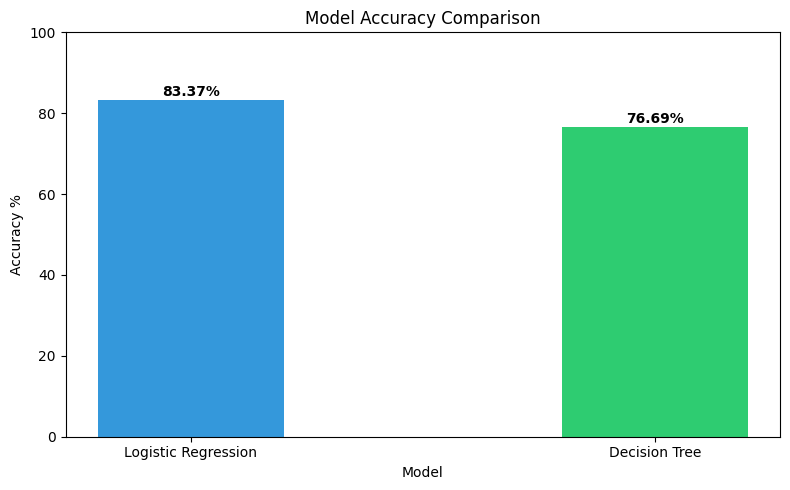

Visualization created successfully! ✅


In [4]:
# Step 5: Visualize the results
models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_accuracy * 100, dt_accuracy * 100]
colors = ['#3498db', '#2ecc71']

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=colors, width=0.4)
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy %')
plt.ylim([0, 100])
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Visualization created successfully! ✅")

In [5]:
# Step 6: Predict rainfall for new data
def predict_rain(MinTemp, MaxTemp, Rainfall, Humidity9am,
                 Humidity3pm, Pressure9am, Pressure3pm,
                 Temp9am, Temp3pm, RainToday):

    input_data = pd.DataFrame([[MinTemp, MaxTemp, Rainfall, Humidity9am,
                                 Humidity3pm, Pressure9am, Pressure3pm,
                                 Temp9am, Temp3pm, RainToday]],
                               columns=['MinTemp', 'MaxTemp', 'Rainfall',
                                       'Humidity9am', 'Humidity3pm',
                                       'Pressure9am', 'Pressure3pm',
                                       'Temp9am', 'Temp3pm', 'RainToday'])

    prediction = lr_model.predict(input_data)
    probability = lr_model.predict_proba(input_data)

    if prediction[0] == 1:
        print("Weather Input: MinTemp={}, MaxTemp={}, Humidity={}%".format(MinTemp, MaxTemp, Humidity3pm))
        print("Prediction: RAIN TOMORROW - {:.1f}% confidence".format(probability[0][1]*100))
    else:
        print("Weather Input: MinTemp={}, MaxTemp={}, Humidity={}%".format(MinTemp, MaxTemp, Humidity3pm))
        print("Prediction: NO RAIN TOMORROW - {:.1f}% confidence".format(probability[0][0]*100))
    print("-" * 50)

# Test predictions
print("RAINFALL PREDICTIONS:")
print("=" * 50)
predict_rain(20, 35, 0, 60, 80, 1010, 1008, 25, 32, 0)
predict_rain(10, 15, 10, 90, 95, 1005, 1003, 12, 14, 1)
predict_rain(15, 25, 0, 50, 55, 1015, 1013, 18, 23, 0)

RAINFALL PREDICTIONS:
Weather Input: MinTemp=20, MaxTemp=35, Humidity=80%
Prediction: RAIN TOMORROW - 60.4% confidence
--------------------------------------------------
Weather Input: MinTemp=10, MaxTemp=15, Humidity=95%
Prediction: RAIN TOMORROW - 82.7% confidence
--------------------------------------------------
Weather Input: MinTemp=15, MaxTemp=25, Humidity=55%
Prediction: NO RAIN TOMORROW - 80.4% confidence
--------------------------------------------------
